In [1]:
import pathlib, importlib.util, sys
import numpy as np
import matplotlib.pyplot as plt

model_path = pathlib.Path("paleochannel_phase_validation_advanced_v5.py")
spec = importlib.util.spec_from_file_location("paleo_adv", str(model_path))
mod = importlib.util.module_from_spec(spec)
sys.modules[spec.name] = mod
spec.loader.exec_module(mod)

import paleochannel_dielectric_estimator_v5 as est
from paleochannel_dielectric_estimator_v5 import mc_amplitude_phase_to_dielectric, mc_coherence_to_depth

print("Modules loaded.")
print(f"Bir Safsaf permittivities (Paillou et al. 2003, Table I):")
print(f"  MSS (surface):  {mod.EPS_MSS}")
print(f"  CSL:            {mod.EPS_CSL}")
print(f"  SPA (bg layer): {mod.EPS_SPA}")
print(f"  CPG (target):   {mod.EPS_CPG}")
print(f"  NSB (bedrock):  {mod.EPS_NSB}")


Modules loaded.
Bir Safsaf permittivities (Paillou et al. 2003, Table I):
  MSS (surface):  (2.85-0.05j)
  CSL:            (2.95-0.08j)
  SPA (bg layer): (3.15-0.15j)
  CPG (target):   (3.8-0.17j)
  NSB (bedrock):  (3.55-0.16j)


In [2]:
# =============================================================================
#  PARAMETERS — edit this cell to change the scene, then re-run all cells
# =============================================================================

# --- Scene preset ---------------------------------------------------------
# Choose one: "single_cpg"  "multilayer"  "nsb"  "custom"
SCENE_PRESET = "single_cpg"

# --- Reflector depth [m] --------------------------------------------------
# Physical burial depth of the CPG layer below the MSS surface.
# Bir Safsaf stratigraphic range: 1.0 m (shallow) to 2.5 m (deep).
# Midpoint (default): 1.5 m
CPG_DEPTH_M = 1.5

# --- Dielectric constants (only used when SCENE_PRESET = "custom") --------
# Use mod.EPS_MSS / EPS_SPA / EPS_CPG / EPS_NSB for Bir Safsaf values.
CUSTOM_EPS_SURFACE   = mod.EPS_MSS      # surface (background) permittivity
CUSTOM_EPS_BG_LAYER  = mod.EPS_SPA      # inter-channel permittivity at depth
CUSTOM_EPS_CH_LAYER  = mod.EPS_CPG      # channel (buried target) permittivity

# --- Dielectric mode for MC (cell 25) -------------------------------------
# "topp"          moisture → epsilon (Topp 1980 + Lasne 2008)  [default, recommended]
# "crim"          Complex Refractive Index Model (Mironov 2004)
# "dobson_simple" Dobson mixing approximation
# "constant"      fixed eps — moisture perturbations have no effect on epsilon
MC_DIELECTRIC_MODE = "topp"

# --- Channel geometry ------------------------------------------------------
CHANNEL_HALF_WIDTH_M   = 140.0    # Gaussian half-width of channel [m]
CHANNEL_SINU_AMP_M     = 120.0    # sinusoidal amplitude of centreline [m]
CHANNEL_SINU_PERIOD_M  = 1400.0   # period of sinusoidal meandering [m]

# --- Surface roughness -----------------------------------------------------
BG_ROUGHNESS_RMS_M  = 0.010   # background (MSS fine sand) [m]
CH_ROUGHNESS_RMS_M  = 0.035   # channel fill (coarser CPG material) [m]

# --- Moisture (used when MC_DIELECTRIC_MODE != "constant") -----------------
BG_MOISTURE   = 0.01   # background volumetric moisture [m³/m³]  (<1% hyperarid)
CH_MOISTURE   = 0.05   # channel moisture (slightly elevated)

# --- Noise / coherence parameters ------------------------------------------
AMP_NOISE_BG    = 0.04    # amplitude noise std, background
AMP_NOISE_CH    = 0.12    # amplitude noise std, channel
PHASE_NOISE_BG  = 0.08    # phase noise std [rad], background
PHASE_NOISE_CH  = 0.35    # phase noise std [rad], channel
TEMP_COH_BG     = 0.92    # temporal coherence, background
TEMP_COH_CH     = 0.72    # temporal coherence, channel
SNR_DB          = 12.0    # signal-to-noise ratio [dB]

# --- BIOMASS acquisition geometry ------------------------------------------
THETA_MIN_DEG   = 23.0      # minimum incidence angle [deg]
THETA_MAX_DEG   = 28.0      # maximum incidence angle [deg]
B_PERP_M        = 800.0     # perpendicular baseline [m]
SLANT_RANGE_M   = 734_000.0 # slant range [m]

# --- Grid size (reduce for speed, increase for resolution) -----------------
NX = 240
NY = 120

# --- Monte Carlo settings --------------------------------------------------
MC_N_REALIZATIONS = 200   # forward-parameter MC realizations
MC_COH_N_REAL     = 500   # coherence MC realizations

# =============================================================================
print(f"Scene preset:         {SCENE_PRESET}")
print(f"CPG depth:            {CPG_DEPTH_M} m")
print(f"Channel half-width:   {CHANNEL_HALF_WIDTH_M} m")
print(f"Background roughness: {BG_ROUGHNESS_RMS_M*100:.1f} cm  |  Channel: {CH_ROUGHNESS_RMS_M*100:.1f} cm")
print(f"MC dielectric mode:   {MC_DIELECTRIC_MODE}")
print(f"Grid:                 {NX} × {NY} pixels")


Scene preset:         single_cpg
CPG depth:            1.5 m
Channel half-width:   140.0 m
Background roughness: 1.0 cm  |  Channel: 3.5 cm
MC dielectric mode:   topp
Grid:                 240 × 120 pixels


In [3]:
# Build the scene configuration from the parameters above.
# Re-run this cell (and everything below) whenever you change PARAMETERS.

from dataclasses import replace

_shared = dict(
    nx=NX, ny=NY,
    channel_half_width_m=CHANNEL_HALF_WIDTH_M,
    channel_sinu_amp_m=CHANNEL_SINU_AMP_M,
    channel_sinu_period_m=CHANNEL_SINU_PERIOD_M,
    background_roughness_rms_m=BG_ROUGHNESS_RMS_M,
    channel_roughness_rms_m=CH_ROUGHNESS_RMS_M,
    background_moisture=BG_MOISTURE,
    channel_moisture=CH_MOISTURE,
    amp_noise_std_background=AMP_NOISE_BG,
    amp_noise_std_channel=AMP_NOISE_CH,
    phase_noise_std_background_rad=PHASE_NOISE_BG,
    phase_noise_std_channel_rad=PHASE_NOISE_CH,
    temporal_coherence_background=TEMP_COH_BG,
    temporal_coherence_channel=TEMP_COH_CH,
    snr_db=SNR_DB,
    theta_min_deg=THETA_MIN_DEG,
    theta_max_deg=THETA_MAX_DEG,
    b_perp_m=B_PERP_M,
    slant_range_m=SLANT_RANGE_M,
)

if SCENE_PRESET == "single_cpg":
    cfg = mod.bir_safsaf_single_cpg(cpg_depth_m=CPG_DEPTH_M, **_shared)

elif SCENE_PRESET == "multilayer":
    cfg = mod.bir_safsaf_multilayer(**_shared)
    # Override the CPG depth in the multilayer stack (third layer)
    new_layers = list(cfg.layers)
    new_layers[2] = replace(new_layers[2], depth_m=CPG_DEPTH_M)
    cfg = replace(cfg, layers=tuple(new_layers))

elif SCENE_PRESET == "nsb":
    cfg = mod.bir_safsaf_nsb(**_shared)
    new_layers = list(cfg.layers)
    new_layers[0] = replace(new_layers[0], depth_m=CPG_DEPTH_M)
    cfg = replace(cfg, layers=tuple(new_layers))

elif SCENE_PRESET == "custom":
    from paleochannel_phase_validation_advanced_v5 import LayerConfig
    cfg = mod.bir_safsaf_single_cpg(cpg_depth_m=CPG_DEPTH_M, **_shared)
    cfg = replace(
        cfg,
        dielectric_mode="constant",
        background_epsilon_complex=CUSTOM_EPS_SURFACE,
        channel_epsilon_complex=CUSTOM_EPS_SURFACE,
        layers=(
            LayerConfig(
                epsilon_background=CUSTOM_EPS_BG_LAYER,
                epsilon_channel=CUSTOM_EPS_CH_LAYER,
                depth_m=CPG_DEPTH_M,
                amplitude=0.28,
                scale_by_membership=True,
                depth_follows_channel=True,
            ),
        ),
    )
else:
    raise ValueError(f"Unknown SCENE_PRESET: {SCENE_PRESET!r}. "
                     "Choose single_cpg | multilayer | nsb | custom")

# Run the simulation
res = mod.simulate_paleochannel_advanced(cfg)

# Convenience aliases used throughout the notebook

print(f"Scene:          {SCENE_PRESET}")
print(f"Grid:           {cfg.nx} × {cfg.ny}  ({cfg.nx*cfg.dx:.0f} × {cfg.ny*cfg.dy:.0f} m)")
print(f"Surface eps*:   {cfg.background_epsilon_complex}  (MSS)")
print(f"Phase contrast: {res.phase_contrast_deg:.2f} deg  (channel − background)")
print(f"InSAR coh range: [{res.gamma_vv_insar.min():.3f}, {res.gamma_vv_insar.max():.3f}]")

# Ground-truth values for the estimator cells — set here so they update
# automatically whenever CPG_DEPTH_M or SCENE_PRESET changes.
truth_eps   = cfg.layers[0].epsilon_channel   # CPG: 3.80 - 0.17j  (Paillou et al. 2003)
truth_depth = cfg.layers[0].depth_m           # CPG burial depth [m]
truth_layer_depth = truth_depth               # alias used in MC histogram cell


Scene:          single_cpg
Grid:           240 × 120  (2400 × 1200 m)
Surface eps*:   (2.85-0.05j)  (MSS)
Phase contrast: 12.47 deg  (channel − background)
InSAR coh range: [0.477, 0.863]


In [4]:
eps_bg = cfg.layers[0].epsilon_background   # SPA
eps_ch = cfg.layers[0].epsilon_channel      # CPG

eps_layer_complex = (
    (1.0 - res.channel_membership) * eps_bg
    + res.channel_membership * eps_ch
)

eps_layer_real = np.real(eps_layer_complex)
eps_layer_imag = -np.imag(eps_layer_complex)   # positive loss term epsilon''

<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
<>:4: SyntaxWarning: invalid escape sequence '\e'
<>:5: SyntaxWarning: invalid escape sequence '\e'
<>:24: SyntaxWarning: invalid escape sequence '\e'
<>:25: SyntaxWarning: invalid escape sequence '\e'
C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\1829057558.py:4: SyntaxWarning: invalid escape sequence '\e'
  (eps_layer_real,          "Buried layer real $\epsilon'$ (SPA$\to$CPG)", "viridis"),
C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\1829057558.py:5: SyntaxWarning: invalid escape sequence '\e'
  (eps_layer_imag,          "Buried layer imag $\epsilon''$ (SPA$\to$CPG)", "magma"),
C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\1829057558.py:24: SyntaxWarning: invalid escape sequence '\e'
  "Surface: MSS ($\epsilon^*=2.85-0.05j$);  "
C:\Users\Femke.G

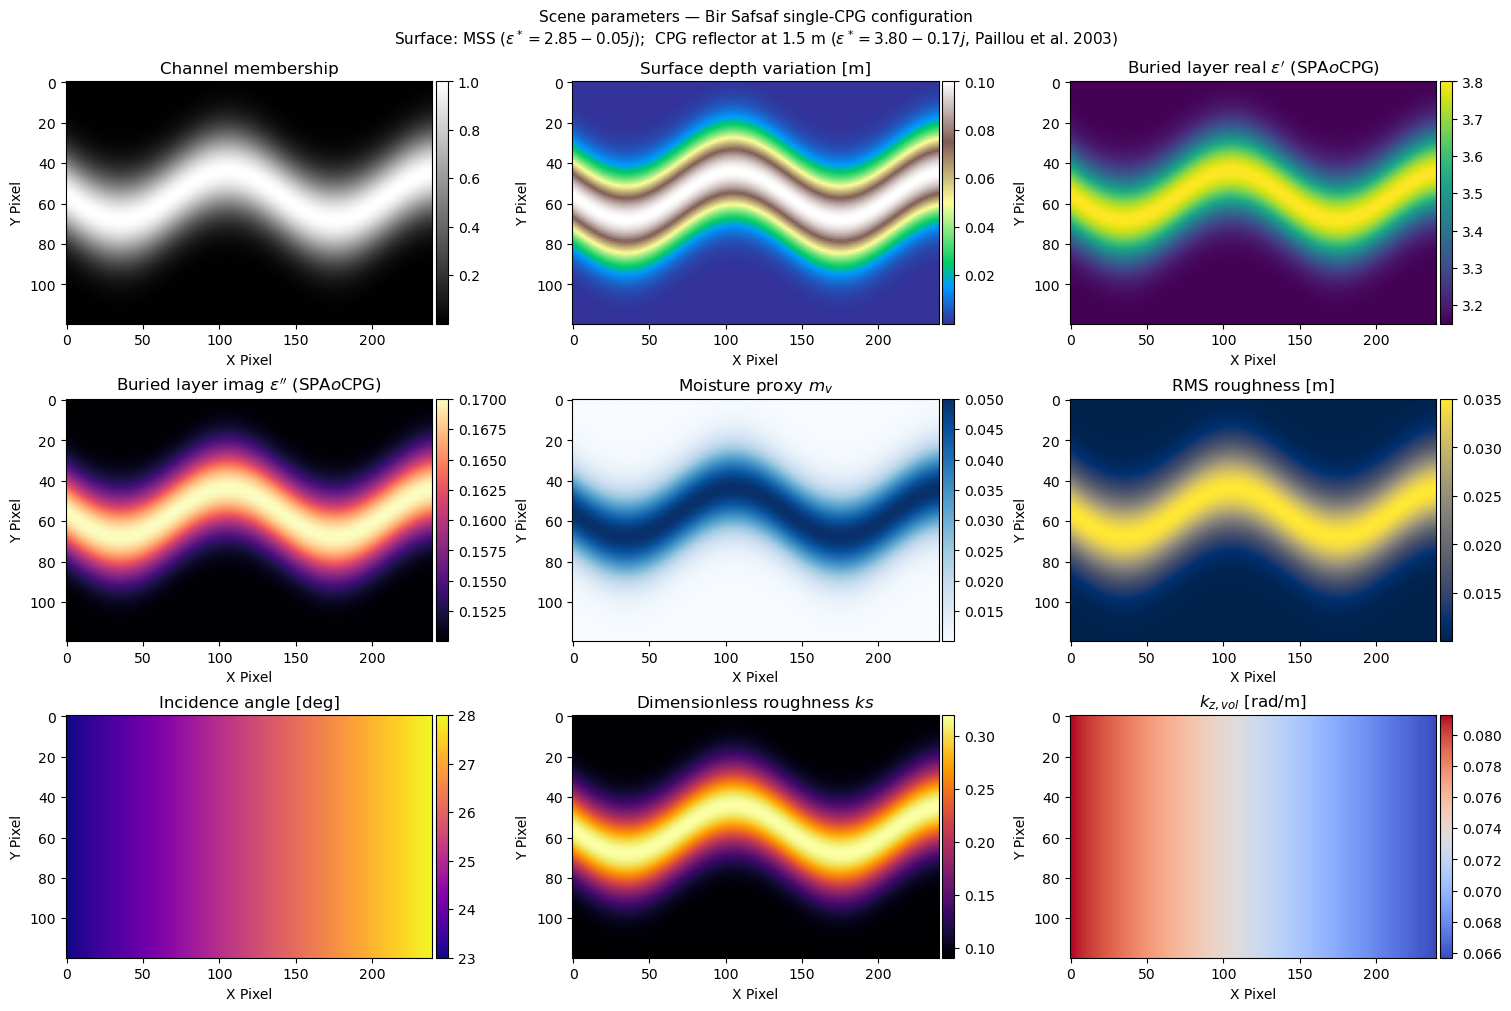

In [5]:
fields = [
    (res.channel_membership,  "Channel membership",                         "gray"),
    (res.surface_depth_m,     "Surface depth variation [m]",                "terrain"),
    (eps_layer_real,          "Buried layer real $\epsilon'$ (SPA$\to$CPG)", "viridis"),
    (eps_layer_imag,          "Buried layer imag $\epsilon''$ (SPA$\to$CPG)", "magma"),
    (res.moisture_map,        "Moisture proxy $m_v$",                       "Blues"),
    (res.roughness_rms_m,     "RMS roughness [m]",                          "cividis"),
    (res.incidence_angle_deg, "Incidence angle [deg]",                      "plasma"),
    (res.ks,                  "Dimensionless roughness $ks$",               "inferno"),
    (res.kz_volume_rad_per_m, "$k_{z,vol}$ [rad/m]",                        "coolwarm"),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 10), constrained_layout=True)

for ax, (arr, title, cmap) in zip(axs.ravel(), fields):
    im = ax.imshow(arr, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("X Pixel")
    ax.set_ylabel("Y Pixel")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

fig.suptitle(
    "Scene parameters — Bir Safsaf single-CPG configuration\n"
    "Surface: MSS ($\epsilon^*=2.85-0.05j$);  "
    "CPG reflector at 1.5 m ($\epsilon^*=3.80-0.17j$, Paillou et al. 2003)",
    fontsize=11
)

plt.show()

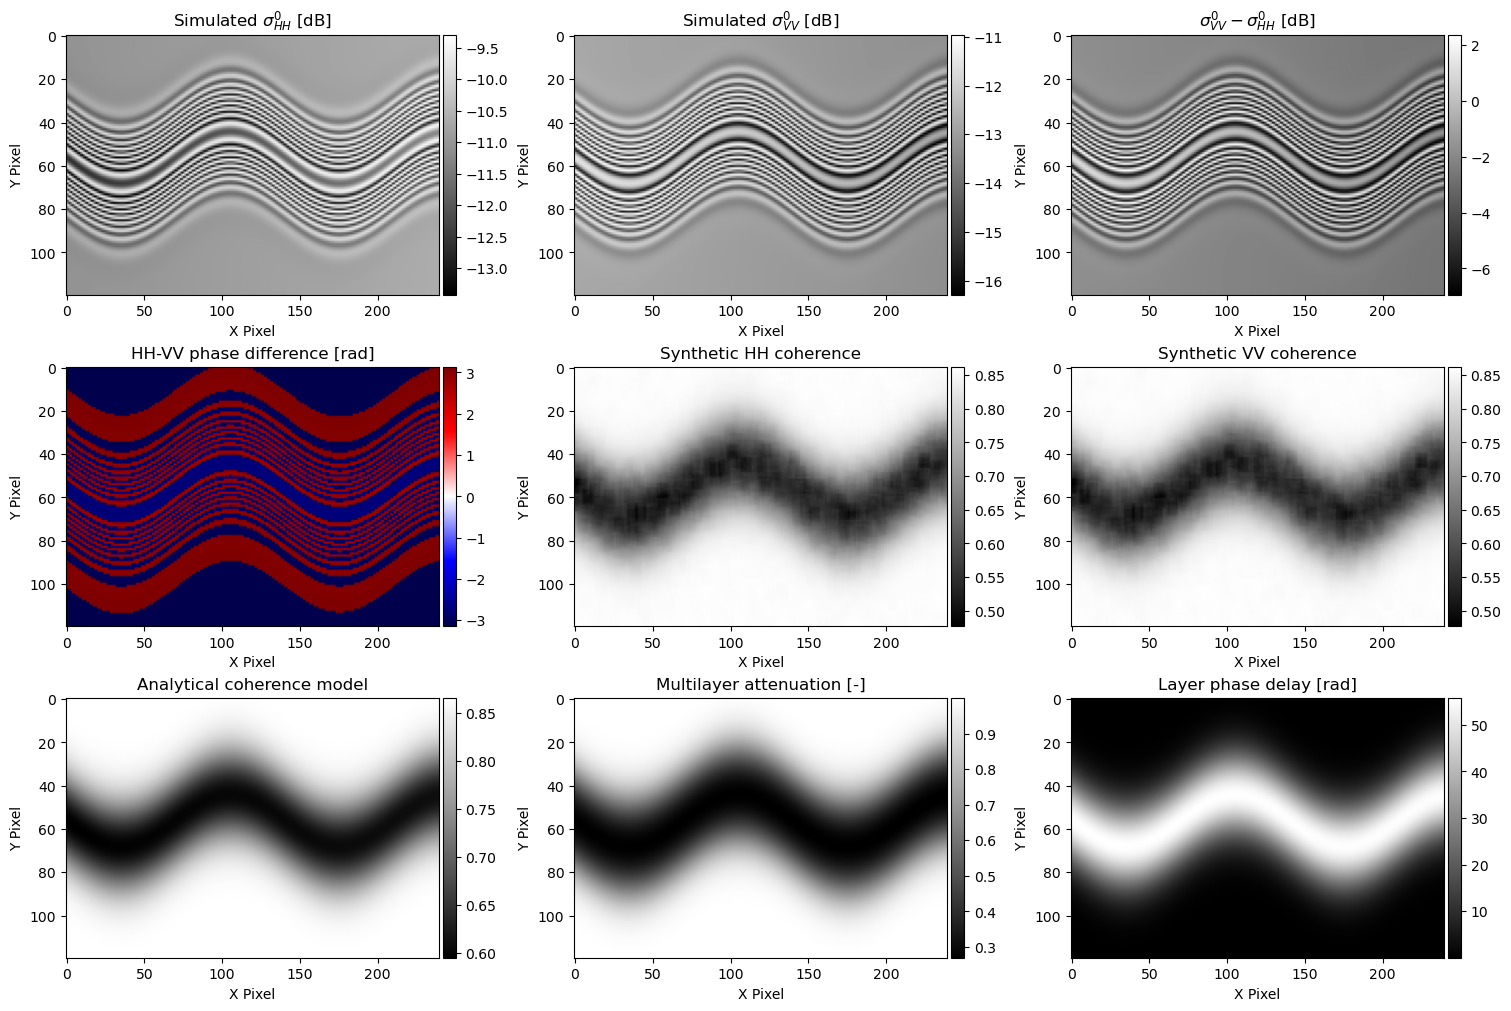

In [6]:
fields = [
    (res.sigma0_hh_db, "Simulated $\\sigma^0_{HH}$ [dB]"),
    (res.sigma0_vv_db, "Simulated $\\sigma^0_{VV}$ [dB]"),
    (res.sigma0_vv_db - res.sigma0_hh_db, "$\\sigma^0_{VV}-\\sigma^0_{HH}$ [dB]"),
    (res.phi_hhvv_rad, "HH-VV phase difference [rad]"),
    (res.gamma_hh_sim, "Synthetic HH coherence"),
    (res.gamma_vv_sim, "Synthetic VV coherence"),
    (res.gamma_model, "Analytical coherence model"),
    (res.layer_attenuation, "Multilayer attenuation [-]"),
    (res.layer_phase_delay_rad, "Layer phase delay [rad]"),
]

fig, axs = plt.subplots(3, 3, figsize=(15, 10), constrained_layout=True)

for ax, (arr, title) in zip(axs.ravel(), fields):
    cmap = "seismic" if "phase difference" in title else "gray"
    im = ax.imshow(arr, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("X Pixel")
    ax.set_ylabel("Y Pixel")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)

plt.show()

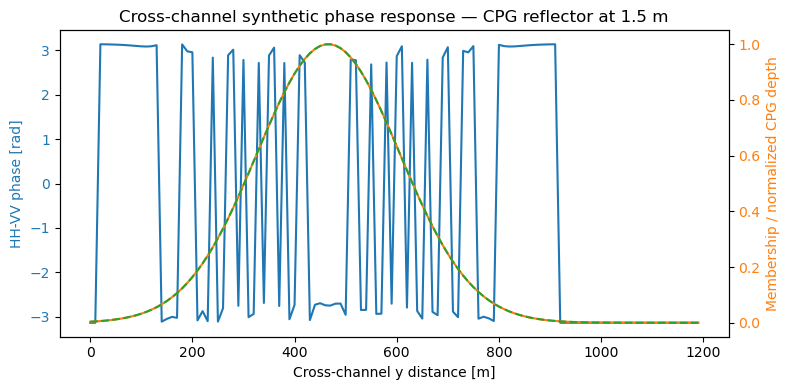

In [7]:
x_idx = res.channel_membership.shape[1] // 2
y_m = res.y

fig, ax1 = plt.subplots(figsize=(8, 4))

ax1.plot(y_m, res.phi_hhvv_rad[:, x_idx], color="tab:blue", label="HH-VV phase")
ax1.set_xlabel("Cross-channel y distance [m]")
ax1.set_ylabel("HH-VV phase [rad]", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
ax2.plot(y_m, res.channel_membership[:, x_idx], color="tab:orange", label="Membership")
ax2.plot(
    y_m,
    res.reflector_depth_m[:, x_idx] / np.nanmax(res.reflector_depth_m),
    color="tab:green",
    linestyle="--",
    label="Normalized CPG depth"
)
ax2.set_ylabel("Membership / normalized CPG depth", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")

plt.title("Cross-channel synthetic phase response — CPG reflector at 1.5 m")
fig.tight_layout()
plt.show()


### Extracting a multi-angle profile from one synthetic scene

The channel's centerline (`profile_membership` ≈ 1 throughout) crosses the full incidence-angle range already configured via `theta_min_deg`/`theta_max_deg`. Sampling along it gives several independent "looks" at essentially the same buried material from a single forward simulation — exactly the kind of angle diversity a real BIOMASS swath provides.

In [8]:
center_idx = np.clip(np.round(mod._channel_centerline(res.x, cfg) / max(cfg.dy, 1e-9)).astype(int), 0, cfg.ny - 1)
x_idx = np.arange(cfg.nx)

theta_profile   = res.incidence_angle_deg[center_idx, x_idx]
sigma0_vv_profile = res.sigma0_vv_db[center_idx, x_idx]
sigma0_hh_profile = res.sigma0_hh_db[center_idx, x_idx]
phi_profile     = res.phi_hhvv_rad[center_idx, x_idx]
M_profile       = res.channel_membership[center_idx, x_idx]

# Bir Safsaf CPG ground truth

print(f"Centerline incidence angle range: {theta_profile.min():.1f} - {theta_profile.max():.1f} deg")

Centerline incidence angle range: 23.0 - 28.0 deg


### The single-angle degeneracy

Before trusting any estimate, check whether the observables even pin down a unique answer. At one incidence angle, with depth assumed known, is (sigma0_HH, sigma0_VV, phase) — three numbers — actually enough to uniquely fix complex permittivity — two numbers?

In [9]:
theta1 = theta_profile[:1]
M1 = M_profile[:1]

pred_truth = est.forward_channel_response(truth_eps, truth_depth, cfg, theta1, membership=M1)

single_fit = est.estimate_channel_permittivity(
    theta1, pred_truth["sigma0_vv_db"], pred_truth["sigma0_hh_db"], pred_truth["phi_hhvv_rad"],
    cfg, channel_depth_m=truth_depth, n_restarts=20,
)
fitted_eps = single_fit["epsilon_complex"]
pred_fitted = est.forward_channel_response(fitted_eps, truth_depth, cfg, theta1, membership=M1)

print(f"True CPG permittivity:    eps={truth_eps}  (Paillou et al. 2003 Table I)")
print(f"Alternative exact fit:    {fitted_eps:.3f}   (residual RMSE: {single_fit['residual_rmse']:.6f})")
print()
print(f"Predicted observables at theta = {float(theta1[0]):.1f} deg:")
print(f"  true eps:   sigma0_vv={pred_truth['sigma0_vv_db'][0]:.3f} dB  sigma0_hh={pred_truth['sigma0_hh_db'][0]:.3f} dB  phase={np.rad2deg(pred_truth['phi_hhvv_rad'][0]):.2f} deg")
print(f"  fitted eps: sigma0_vv={pred_fitted['sigma0_vv_db'][0]:.3f} dB  sigma0_hh={pred_fitted['sigma0_hh_db'][0]:.3f} dB  phase={np.rad2deg(pred_fitted['phi_hhvv_rad'][0]):.2f} deg")
print()
print("Two genuinely different permittivities, observationally indistinguishable at a single angle.")

C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\681472837.py:6: DeprecationWarning: estimate_channel_permittivity is deprecated: it fits (eps_real, eps_imag) from co-pol phase, but eps_imag is unidentifiable from co-pol sigma0 at P-band. Use estimate_surface_dielectric_roughness (LUT, linear, (eps_real, ks)) instead.
  single_fit = est.estimate_channel_permittivity(


True CPG permittivity:    eps=(3.8-0.17j)  (Paillou et al. 2003 Table I)
Alternative exact fit:    3.024-0.151j   (residual RMSE: 0.000000)

Predicted observables at theta = 23.0 deg:
  true eps:   sigma0_vv=-11.561 dB  sigma0_hh=-12.670 dB  phase=-161.52 deg
  fitted eps: sigma0_vv=-11.561 dB  sigma0_hh=-12.670 dB  phase=-161.52 deg

Two genuinely different permittivities, observationally indistinguishable at a single angle.


### Multi-angle, depth known

Now use the full centerline profile (angle diversity) instead of one pixel, still holding depth at its true value.

In [10]:
multi_step = 20  # every 20th pixel along the centerline -> ~12 looks spanning the full incidence-angle range
theta_multi = theta_profile[::multi_step]
vv_multi = sigma0_vv_profile[::multi_step]
hh_multi = sigma0_hh_profile[::multi_step]
phi_multi = phi_profile[::multi_step]

fit_known_depth = est.estimate_channel_permittivity(
    theta_multi, vv_multi, hh_multi, phi_multi, cfg,
    channel_depth_m=truth_depth, n_restarts=80, rng_seed=1,
)

print(f"True (CPG, Paillou 2003): eps_real={truth_eps.real:.2f}  eps_imag={-truth_eps.imag:.3f}  (depth held fixed at {truth_depth:.2f} m)")
print(f"Estimated: eps_real={fit_known_depth['eps_real']:.2f}  eps_imag={fit_known_depth['eps_imag']:.2f}")
print(fit_known_depth["note"])

C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\3359792628.py:7: DeprecationWarning: estimate_channel_permittivity is deprecated: it fits (eps_real, eps_imag) from co-pol phase, but eps_imag is unidentifiable from co-pol sigma0 at P-band. Use estimate_surface_dielectric_roughness (LUT, linear, (eps_real, ks)) instead.
  fit_known_depth = est.estimate_channel_permittivity(


True (CPG, Paillou 2003): eps_real=3.80  eps_imag=0.170  (depth held fixed at 1.50 m)
Estimated: eps_real=3.80  eps_imag=0.17
62 distinct local minima found across 80 restarts — if this is more than 1–2, treat the point estimate with caution and inspect the cost landscape (see identifiability_scan) before trusting it.


### Multi-angle, depth unknown — the realistic case

In practice you usually don't know the buried layer's depth independently. Estimate it jointly with permittivity instead.

In [11]:
fit_unknown_depth = est.estimate_channel_permittivity(
    theta_multi, vv_multi, hh_multi, phi_multi, cfg,
    channel_depth_m=None, n_restarts=150, rng_seed=1,
)

print(f"True (CPG): eps_real={truth_eps.real:.2f}  eps_imag={-truth_eps.imag:.3f}  depth={truth_depth:.2f} m")
print(f"Estimated: eps_real={fit_unknown_depth['eps_real']:.2f}  eps_imag={fit_unknown_depth['eps_imag']:.2f}  depth={fit_unknown_depth['depth_m']:.2f} m")
print(fit_unknown_depth["note"])
print()
print("Depth and permittivity trade off against each other even with full angle diversity --")
print("this is why an independent depth constraint (e.g. multi-baseline InSAR coherence)")
print("matters so much for making the permittivity estimate trustworthy.")

C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\1003511156.py:1: DeprecationWarning: estimate_channel_permittivity is deprecated: it fits (eps_real, eps_imag) from co-pol phase, but eps_imag is unidentifiable from co-pol sigma0 at P-band. Use estimate_surface_dielectric_roughness (LUT, linear, (eps_real, ks)) instead.
  fit_unknown_depth = est.estimate_channel_permittivity(


True (CPG): eps_real=3.80  eps_imag=0.170  depth=1.50 m
Estimated: eps_real=2.51  eps_imag=0.17  depth=1.22 m
145 distinct local minima found across 150 restarts — if this is more than 1–2, treat the point estimate with caution and inspect the cost landscape (see identifiability_scan) before trusting it.

Depth and permittivity trade off against each other even with full angle diversity --
this is why an independent depth constraint (e.g. multi-baseline InSAR coherence)
matters so much for making the permittivity estimate trustworthy.


### Visualizing why: the identifiability scan

A point estimate alone can't show you whether you landed in a sharp, well-defined minimum or a shallow ridge of nearly-as-good alternatives. This scans the cost directly over a grid of (eps_real, eps_imag) with depth held at truth.

C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\507219975.py:1: DeprecationWarning: identifiability_scan (over eps_real, eps_imag) is deprecated: use identifiability_scan_lut (over eps_real, ks) for the real method.
  scan = est.identifiability_scan(theta_multi, vv_multi, hh_multi, phi_multi, cfg, channel_depth_m=truth_depth)


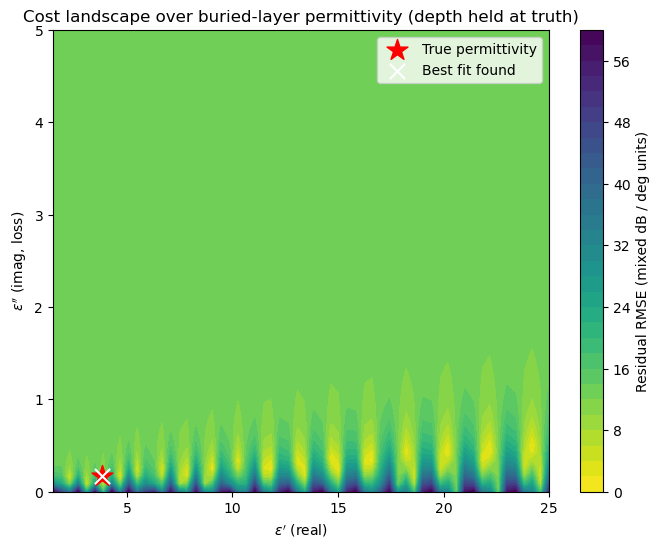

In [12]:
scan = est.identifiability_scan(theta_multi, vv_multi, hh_multi, phi_multi, cfg, channel_depth_m=truth_depth)

fig, ax = plt.subplots(figsize=(8, 6))
cs = ax.contourf(scan["eps_real_grid"], scan["eps_imag_grid"], scan["rmse_grid"], levels=30, cmap="viridis_r")
fig.colorbar(cs, ax=ax, label="Residual RMSE (mixed dB / deg units)")
ax.scatter([truth_eps.real], [-truth_eps.imag], color="red", marker="*", s=250, label="True permittivity", zorder=5)
ax.scatter([fit_known_depth["eps_real"]], [fit_known_depth["eps_imag"]], color="white", marker="x", s=120, label="Best fit found", zorder=5)
ax.set_xlabel("$\\epsilon'$ (real)")
ax.set_ylabel("$\\epsilon''$ (imag, loss)")
ax.set_title("Cost landscape over buried-layer permittivity (depth held at truth)")
ax.legend()
plt.show()

## Monte Carlo uncertainty: epsilon, moisture, and depth

`epsilon_complex`, `moisture_map`, and `depth_map_m` are deterministic given `cfg` — they have no uncertainty by themselves. What's actually uncertain in practice is the *inputs* that define them: how well you really know the channel's moisture contrast, its burial depth, the soil texture, the baseline geometry, the SNR. `monte_carlo_uncertainty` (added directly to `paleochannel_phase_validation_advanced.py`) draws randomized versions of `cfg` from realistic per-parameter uncertainty (`MonteCarloUncertaintyConfig`, overridable), re-runs the forward model for each, and reports the resulting per-pixel spread.

One detail worth flagging: "depth" here is `depth_map_m + layers[0].depth_m * channel_membership`, not `depth_map_m` alone — the layer's own `depth_m` addition isn't included in `depth_map_m` by itself, but it's what actually sets the two-way travel time to the reflecting interface, so leaving it out would understate both the nominal depth and its uncertainty.

In [13]:
# MC uses the dielectric mode set in the PARAMETERS cell (MC_DIELECTRIC_MODE).
# In "topp" mode, moisture perturbations propagate into epsilon.
# In "constant" mode, epsilon std will be ~0 (surface eps fixed to MSS).
cfg_mc = replace(cfg, dielectric_mode=MC_DIELECTRIC_MODE)
mc_result = mod.monte_carlo_uncertainty(cfg_mc, n_realizations=MC_N_REALIZATIONS, rng_seed=0)
print(f"Realizations: {mc_result.n_realizations}  (failed: {mc_result.failed_realizations})")
print(f"Dielectric mode: {MC_DIELECTRIC_MODE}")


Realizations: 200  (failed: 0)
Dielectric mode: topp


### Uncertainty maps

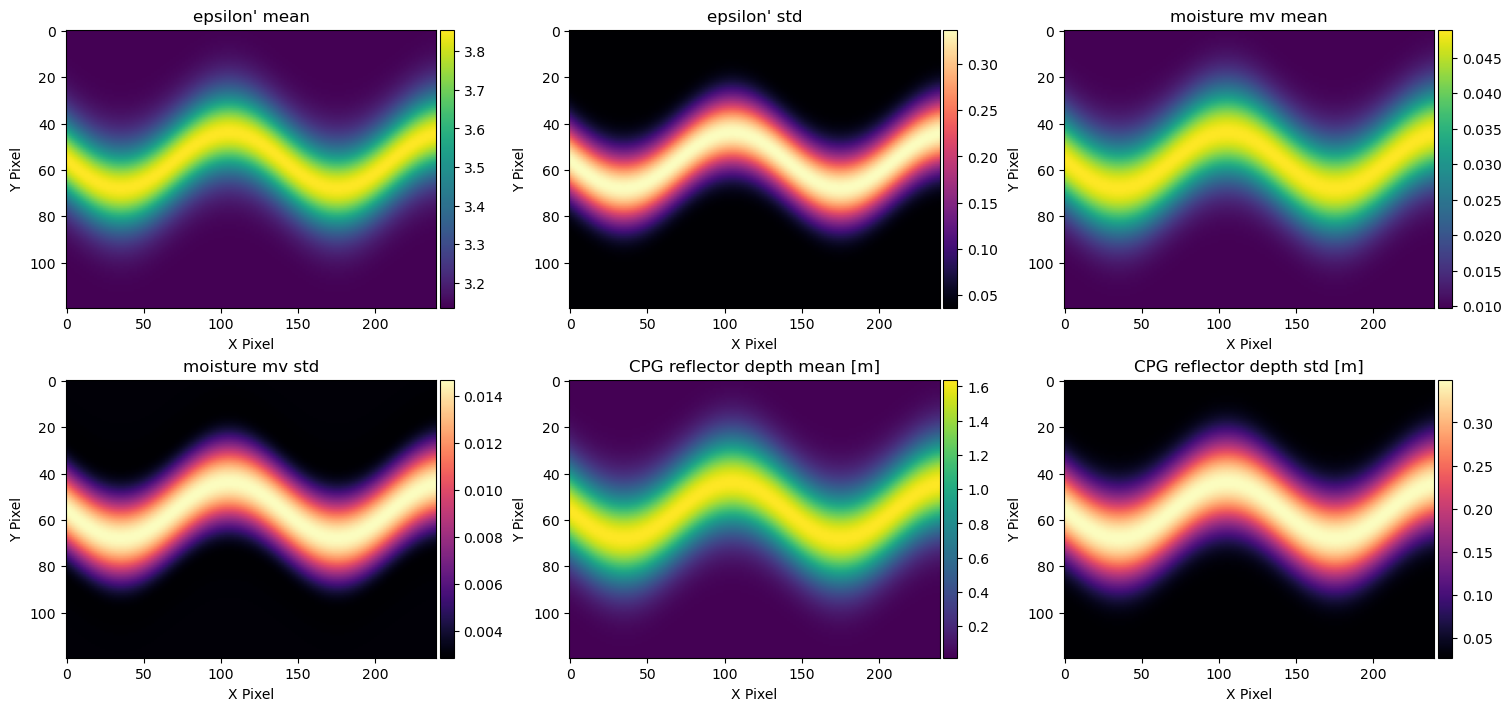

In [14]:
fields = [
    (mc_result.eps_real_mean, "epsilon' mean", "viridis"),
    (mc_result.eps_real_std, "epsilon' std", "magma"),
    (mc_result.mv_mean, "moisture mv mean", "viridis"),
    (mc_result.mv_std, "moisture mv std", "magma"),
    (mc_result.reflector_depth_mean, "CPG reflector depth mean [m]", "viridis"),
    (mc_result.reflector_depth_std, "CPG reflector depth std [m]", "magma"),
]

fig, axs = plt.subplots(2, 3, figsize=(15, 7), constrained_layout=True)
for ax, (arr, title, cmap) in zip(axs.ravel(), fields):
    im = ax.imshow(arr, cmap=cmap, aspect="auto")
    ax.set_title(title)
    ax.set_xlabel("X Pixel")
    ax.set_ylabel("Y Pixel")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.01)
plt.show()

### Cross-channel profile, with uncertainty bands

A single slice through the channel core is usually easier to read than a 2D map when the point is "how much does this value actually vary."

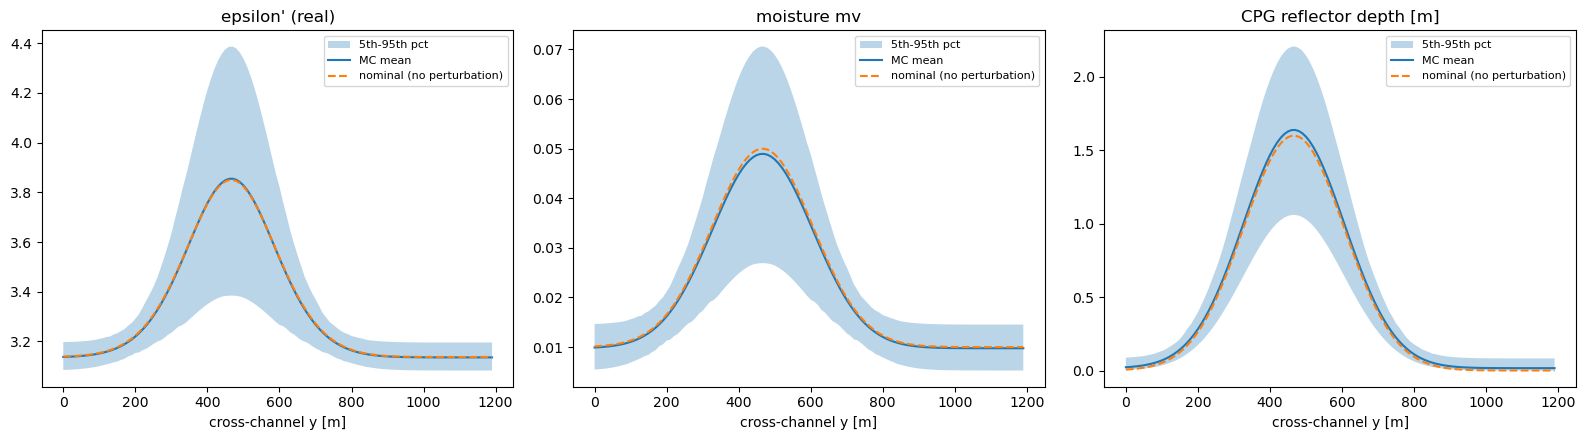

In [15]:
x_idx = cfg.nx // 2
y_m = mc_result.y

fig, axs = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, mean, p05, p95, nominal, label in [
    (axs[0], mc_result.eps_real_mean[:, x_idx], mc_result.eps_real_p05[:, x_idx], mc_result.eps_real_p95[:, x_idx], mc_result.nominal_eps_real[:, x_idx], "epsilon' (real)"),
    (axs[1], mc_result.mv_mean[:, x_idx], mc_result.mv_p05[:, x_idx], mc_result.mv_p95[:, x_idx], mc_result.nominal_mv[:, x_idx], "moisture mv"),
    (axs[2], mc_result.reflector_depth_mean[:, x_idx], mc_result.reflector_depth_p05[:, x_idx], mc_result.reflector_depth_p95[:, x_idx], mc_result.nominal_reflector_depth[:, x_idx], "CPG reflector depth [m]"),
]:
    ax.fill_between(y_m, p05, p95, alpha=0.3, label="5th-95th pct")
    ax.plot(y_m, mean, label="MC mean")
    ax.plot(y_m, nominal, "--", label="nominal (no perturbation)")
    ax.set_title(label)
    ax.set_xlabel("cross-channel y [m]")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

### Channel core vs background, summarized

In [16]:
M = mc_result.channel_membership
core_mask = M >= 0.95
background_mask = M < 0.05

def relative_pct(mean, std, mask):
    m = np.nanmean(mean[mask])
    s = np.nanmean(std[mask])
    return m, s, (s / m * 100.0 if m != 0 else float("nan"))

print(f"{'':10s} {'channel core (mean +/- std, rel%)':45s} {'background (mean +/- std, rel%)':45s}")
for mean_arr, std_arr, label, fmt in [
    (mc_result.eps_real_mean, mc_result.eps_real_std, "epsilon'", "%.2f"),
    (mc_result.mv_mean, mc_result.mv_std, "mv", "%.4f"),
    (mc_result.reflector_depth_mean, mc_result.reflector_depth_std, "depth [m]", "%.2f"),
]:
    cm, cs, cr = relative_pct(mean_arr, std_arr, core_mask)
    bm, bs, br = relative_pct(mean_arr, std_arr, background_mask)
    core_str = f"{fmt % cm} +/- {fmt % cs} ({cr:.0f}%)"
    bg_str = f"{fmt % bm} +/- {fmt % bs} ({br:.0f}%)"
    print(f"{label:10s} {core_str:45s} {bg_str:45s}")

           channel core (mean +/- std, rel%)             background (mean +/- std, rel%)              
epsilon'   3.84 +/- 0.33 (9%)                            3.14 +/- 0.04 (1%)                           
mv         0.0483 +/- 0.0144 (30%)                       0.0101 +/- 0.0030 (29%)                      
depth [m]  1.61 +/- 0.34 (21%)                           0.03 +/- 0.03 (89%)                          


## MC 1: Amplitude & phase noise → dielectric estimator uncertainty


In [17]:
from paleochannel_dielectric_estimator_v5 import mc_amplitude_phase_to_dielectric, mc_coherence_to_depth

center_idx = np.clip(np.round(mod._channel_centerline(res.x, cfg) / max(cfg.dy, 1e-9)).astype(int), 0, cfg.ny - 1)
multi = slice(0, 240, 20)
x_idx = np.arange(cfg.nx)
theta_m  = res.incidence_angle_deg[center_idx, x_idx][multi]
vv_m     = res.sigma0_vv_db[center_idx, x_idx][multi]
hh_m     = res.sigma0_hh_db[center_idx, x_idx][multi]
phi_m    = res.phi_hhvv_rad[center_idx, x_idx][multi]
truth_layer_depth = cfg.layers[0].depth_m   # the depth parameter the estimator fits (2 m)

amp_db   = 8.686 * cfg.amp_noise_std_channel
phase_deg = np.rad2deg(cfg.phase_noise_std_channel_rad)
print(f"Noise applied per look:  amplitude {amp_db:.2f} dB (1-sigma),  phase {phase_deg:.1f} deg (1-sigma)")
print(f"Truth: eps_real=7.0  eps_imag=0.5  layer_depth_param={truth_layer_depth} m\n")

# --- depth known ---
mc_diel_known = mc_amplitude_phase_to_dielectric(
    theta_m, vv_m, hh_m, phi_m, cfg,
    channel_depth_m=truth_layer_depth, n_realizations=200, n_restarts=5, rng_seed=0,
)
print(f"Depth known — 200 realizations, {mc_diel_known['failed']} failed:")
print(f"  eps_real: mean={mc_diel_known['eps_real']['mean']:.2f}  std={mc_diel_known['eps_real']['std']:.2f}  90% range [{mc_diel_known['eps_real']['p05']:.1f}–{mc_diel_known['eps_real']['p95']:.1f}]")
print(f"  eps_imag: mean={mc_diel_known['eps_imag']['mean']:.2f}  std={mc_diel_known['eps_imag']['std']:.2f}  90% range [{mc_diel_known['eps_imag']['p05']:.2f}–{mc_diel_known['eps_imag']['p95']:.2f}]")
print()

# --- depth unknown ---
mc_diel_unknown = mc_amplitude_phase_to_dielectric(
    theta_m, vv_m, hh_m, phi_m, cfg,
    channel_depth_m=None, n_realizations=100, n_restarts=5, rng_seed=0,
)
print(f"Depth unknown — 100 realizations, {mc_diel_unknown['failed']} failed:")
print(f"  eps_real: mean={mc_diel_unknown['eps_real']['mean']:.2f}  std={mc_diel_unknown['eps_real']['std']:.2f}  90% range [{mc_diel_unknown['eps_real']['p05']:.1f}–{mc_diel_unknown['eps_real']['p95']:.1f}]")
print(f"  eps_imag: mean={mc_diel_unknown['eps_imag']['mean']:.2f}  std={mc_diel_unknown['eps_imag']['std']:.2f}  90% range [{mc_diel_unknown['eps_imag']['p05']:.2f}–{mc_diel_unknown['eps_imag']['p95']:.2f}]")
print(f"  depth:    mean={mc_diel_unknown['depth_m']['mean']:.2f}  std={mc_diel_unknown['depth_m']['std']:.2f}  90% range [{mc_diel_unknown['depth_m']['p05']:.1f}–{mc_diel_unknown['depth_m']['p95']:.1f}]  (truth {truth_layer_depth} m)")

Noise applied per look:  amplitude 1.04 dB (1-sigma),  phase 20.1 deg (1-sigma)
Truth: eps_real=7.0  eps_imag=0.5  layer_depth_param=1.5 m



C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\1940847386.py:18: DeprecationWarning: mc_amplitude_phase_to_dielectric is deprecated: use mc_copol_to_dielectric_roughness (LUT-based, linear sigma0).
  mc_diel_known = mc_amplitude_phase_to_dielectric(


Depth known — 200 realizations, 0 failed:
  eps_real: mean=14.94  std=7.50  90% range [4.5–28.7]
  eps_imag: mean=0.74  std=1.80  90% range [0.09–5.32]



C:\Users\Femke.Graveland\AppData\Local\Temp\ipykernel_6080\1940847386.py:28: DeprecationWarning: mc_amplitude_phase_to_dielectric is deprecated: use mc_copol_to_dielectric_roughness (LUT-based, linear sigma0).
  mc_diel_unknown = mc_amplitude_phase_to_dielectric(


Depth unknown — 100 realizations, 0 failed:
  eps_real: mean=14.99  std=9.36  90% range [1.5–30.0]
  eps_imag: mean=2.76  std=2.72  90% range [0.05–8.15]
  depth:    mean=3.46  std=3.36  90% range [0.1–9.6]  (truth 1.5 m)


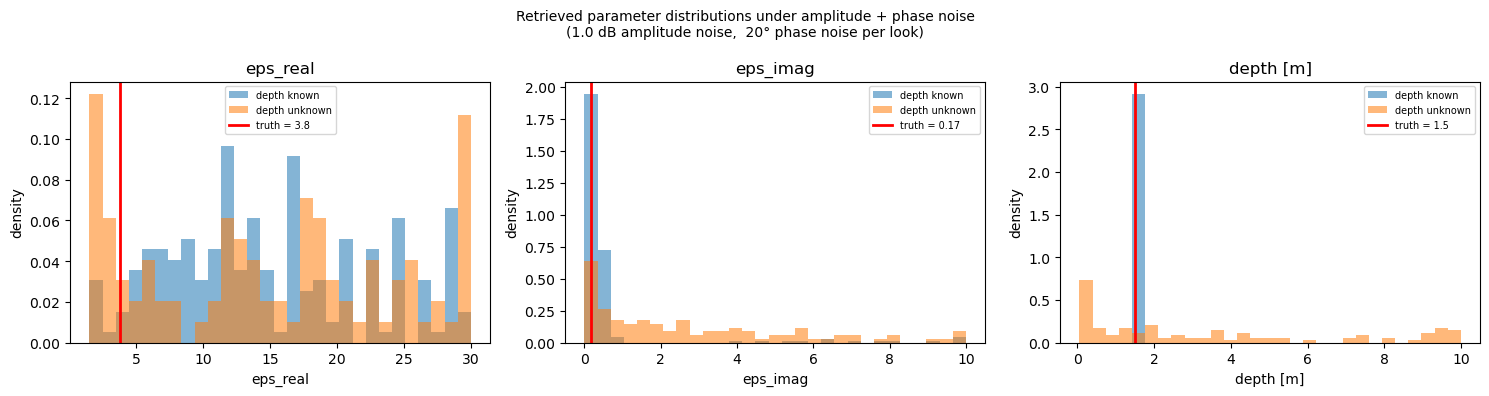

In [18]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))
truth_vals = [truth_eps.real, -truth_eps.imag, float(truth_layer_depth)]
labels = ["eps_real", "eps_imag", "depth [m]"]
keys   = ["eps_real", "eps_imag", "depth_m"]

for ax, key, label, tv in zip(axs, keys, labels, truth_vals):
    s_known = mc_diel_known[key]["samples"]
    s_unknown = mc_diel_unknown[key]["samples"]
    bins = np.linspace(min(s_known.min(), s_unknown.min()), max(s_known.max(), s_unknown.max()), 30)
    ax.hist(s_known, bins=bins, alpha=0.55, label="depth known", density=True)
    ax.hist(s_unknown, bins=bins, alpha=0.55, label="depth unknown", density=True)
    ax.axvline(tv, color="red", linewidth=2, label=f"truth = {tv}")
    ax.set_title(label)
    ax.set_xlabel(label)
    ax.set_ylabel("density")
    ax.legend(fontsize=7)

plt.suptitle("Retrieved parameter distributions under amplitude + phase noise\n"
             f"({amp_db:.1f} dB amplitude noise,  {phase_deg:.0f}° phase noise per look)", fontsize=10)
plt.tight_layout()
plt.show()

## MC 2: Coherence noise → burial depth inversion uncertainty



In [19]:
M = res.channel_membership
gamma_temp_map = (
    cfg.temporal_coherence_background
    + (cfg.temporal_coherence_channel - cfg.temporal_coherence_background) * M
)
kz_vol_map = res.kz_volume_rad_per_m
truth_burial_depth = res.reflector_depth_m  # CPG reflector depth (surface_depth_m + 1.5*M, max ~1.6 m)

mc_coh = mc_coherence_to_depth(
    res.gamma_model, kz_vol_map, cfg,
    n_realizations=MC_COH_N_REAL, gamma_temp=gamma_temp_map, rng_seed=0,
)

snr_lin = 10 ** (cfg.snr_db / 10)
gamma_snr = snr_lin / (1 + snr_lin)

core = M >= 0.95
print(f"Burial depth at channel core:  truth = {truth_burial_depth[core].mean():.4f} m")
print(f"gamma_model at core:           {res.gamma_model[core].mean():.4f}")
print(f"kz_vol at core:                {kz_vol_map[core].mean():.4f} rad/m")
kz_depth_product = (kz_vol_map * truth_burial_depth)[core].mean()
gamma_vol_core = np.exp(-cfg.volume_decorrelation_strength * kz_depth_product)
print(f"kz_vol × depth at core:        {kz_depth_product:.5f} rad  →  gamma_vol = {gamma_vol_core:.5f}")
print(f"Coherence noise σ (N={mc_coh['n_looks']} looks, gamma=0.65): {mc_coh['sigma_gamma'][core].mean():.4f}")
print()
print(f"Signal change from burial (coherence):       {(1-gamma_vol_core)*100:.2f}% coherence reduction")
print(f"Coherence noise floor:                       {mc_coh['sigma_gamma'][core].mean()*100:.2f}% of gamma")
print()
print(f"Depth MC result at channel core:  mean = {mc_coh['depth_mean'][core].mean():.3f} m  std = {mc_coh['depth_std'][core].mean():.3f} m")
print(f"  truth = {truth_burial_depth[core].mean():.4f} m   90% range [{mc_coh['depth_p05'][core].mean():.3f}–{mc_coh['depth_p95'][core].mean():.3f}] m")

Burial depth at channel core:  truth = 1.5729 m
gamma_model at core:           0.6067
kz_vol at core:                0.0730 rad/m
kz_vol × depth at core:        0.11480 rad  →  gamma_vol = 0.89154
Coherence noise σ (N=49 looks, gamma=0.65): 0.0638

Signal change from burial (coherence):       10.85% coherence reduction
Coherence noise floor:                       6.38% of gamma

Depth MC result at channel core:  mean = 1.728 m  std = 1.343 m
  truth = 1.5729 m   90% range [0.000–4.164] m


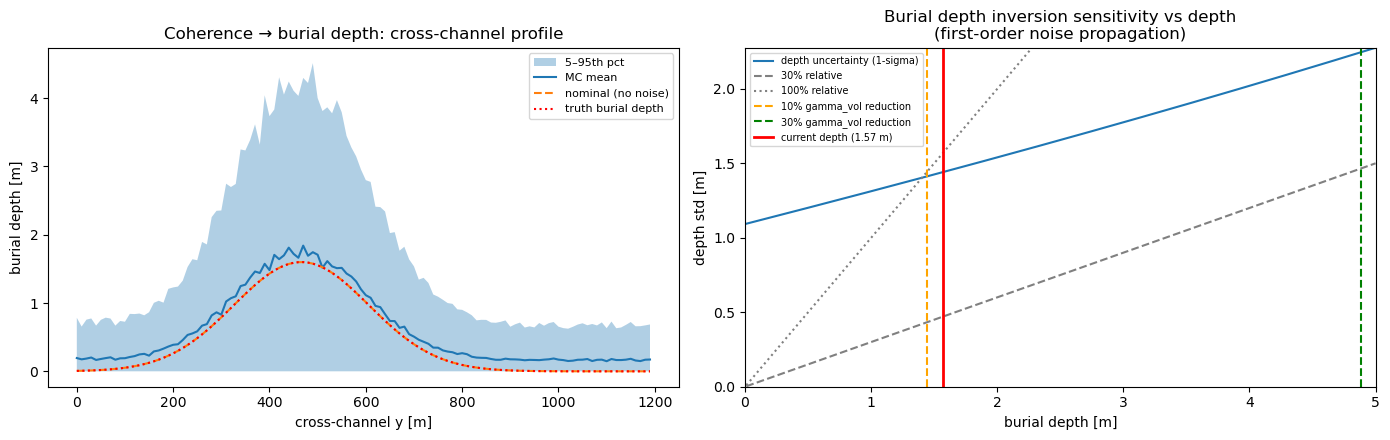

In [20]:
# Cross-channel profile of burial depth with uncertainty
x_mid = cfg.nx // 2
y_m = mc_coh["depth_mean"][:, x_mid] * 0 + res.y   # just the y-axis

fig, axs = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axs[0]
ax.fill_between(res.y, mc_coh["depth_p05"][:, x_mid], mc_coh["depth_p95"][:, x_mid],
                alpha=0.35, label="5–95th pct")
ax.plot(res.y, mc_coh["depth_mean"][:, x_mid], label="MC mean")
ax.plot(res.y, mc_coh["nominal_depth"][:, x_mid], "--", label="nominal (no noise)")
ax.plot(res.y, truth_burial_depth[:, x_mid], "r:", linewidth=1.5, label="truth burial depth")
ax.set_xlabel("cross-channel y [m]")
ax.set_ylabel("burial depth [m]")
ax.set_title("Coherence → burial depth: cross-channel profile")
ax.legend(fontsize=8)

# Sensitivity: how burial depth uncertainty scales with actual burial depth
burial_depths = np.linspace(0.01, 5.0, 200)
kz_mean = float(kz_vol_map[core].mean())
gamma_base = float(res.gamma_model[core].mean())
sigma_g = float(mc_coh["sigma_gamma"][core].mean())
k = cfg.volume_decorrelation_strength

# Noise on gamma_vol_est propagates to depth via d(depth)/d(gamma_vol) = -1/(k*kz*gamma_vol)
gamma_snr_val = snr_lin / (1 + snr_lin)
gamma_temp_core = float(gamma_temp_map[core].mean())
gamma_vol_true = np.exp(-k * kz_mean * burial_depths)
gamma_obs_true = np.clip(gamma_vol_true * gamma_temp_core * gamma_snr_val, 1e-6, 0.9999)
sigma_gamma_d = (1 - gamma_obs_true**2) / np.sqrt(2 * mc_coh["n_looks"])
depth_std_approx = sigma_gamma_d / (k * kz_mean * gamma_obs_true)

ax2 = axs[1]
ax2.plot(burial_depths, depth_std_approx, label="depth uncertainty (1-sigma)")
ax2.plot(burial_depths, burial_depths * 0.3, "--", color="gray", label="30% relative")
ax2.plot(burial_depths, burial_depths * 1.0, ":", color="gray", label="100% relative")
ax2.axvline(-np.log(0.9) / (k * kz_mean), color="orange", linestyle="--", label="10% gamma_vol reduction")
ax2.axvline(-np.log(0.7) / (k * kz_mean), color="green", linestyle="--", label="30% gamma_vol reduction")
ax2.axvline(truth_burial_depth[core].mean(), color="red", linewidth=2, label=f"current depth ({truth_burial_depth[core].mean():.2f} m)")
ax2.set_xlabel("burial depth [m]")
ax2.set_ylabel("depth std [m]")
ax2.set_title("Burial depth inversion sensitivity vs depth\n(first-order noise propagation)")
ax2.legend(fontsize=7)
ax2.set_xlim(0, 5); ax2.set_ylim(0, min(depth_std_approx.max(), 20))

plt.tight_layout()
plt.show()

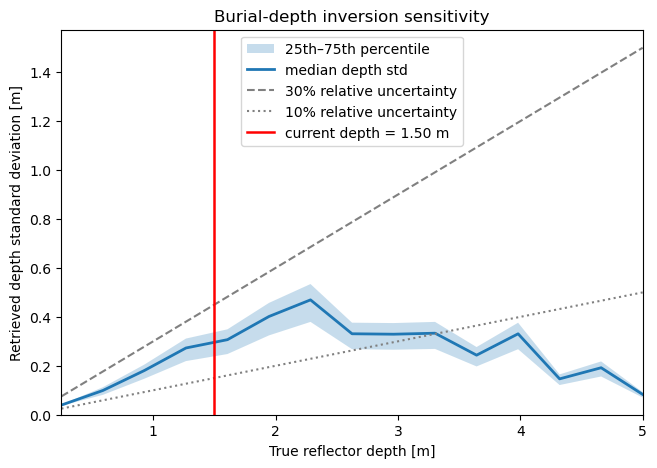

In [21]:
# =============================================================================
# FIGURE 7 — Depth uncertainty versus burial depth
# =============================================================================

# Sweep true CPG depths and run a smaller MC at each depth.
depth_values = np.linspace(0.25, 5.0, 15)
depth_std_median = []
depth_std_p25 = []
depth_std_p75 = []

for d in depth_values:
    cfg_d = mod.bir_safsaf_single_cpg(
        cpg_depth_m=float(d),
        nx=NX,
        ny=NY,
        channel_half_width_m=CHANNEL_HALF_WIDTH_M,
        channel_sinu_amp_m=CHANNEL_SINU_AMP_M,
        channel_sinu_period_m=CHANNEL_SINU_PERIOD_M,
        background_roughness_rms_m=BG_ROUGHNESS_RMS_M,
        channel_roughness_rms_m=CH_ROUGHNESS_RMS_M,
        background_moisture=BG_MOISTURE,
        channel_moisture=CH_MOISTURE,
        amp_noise_std_background=AMP_NOISE_BG,
        amp_noise_std_channel=AMP_NOISE_CH,
        phase_noise_std_background_rad=PHASE_NOISE_BG,
        phase_noise_std_channel_rad=PHASE_NOISE_CH,
        temporal_coherence_background=TEMP_COH_BG,
        temporal_coherence_channel=TEMP_COH_CH,
        snr_db=SNR_DB,
        theta_min_deg=THETA_MIN_DEG,
        theta_max_deg=THETA_MAX_DEG,
        b_perp_m=B_PERP_M,
        slant_range_m=SLANT_RANGE_M,
    )

    mc_d = mod.monte_carlo_uncertainty(
        cfg_d,
        n_realizations=max(50, MC_N_REALIZATIONS // 4),
        rng_seed=100 + int(d * 100),
    )

    M_d = mc_d.channel_membership
    mask_d = M_d > 0.5
    std_vals = mc_d.reflector_depth_std[mask_d]

    depth_std_median.append(np.nanmedian(std_vals))
    depth_std_p25.append(np.nanpercentile(std_vals, 25))
    depth_std_p75.append(np.nanpercentile(std_vals, 75))

depth_std_median = np.asarray(depth_std_median)
depth_std_p25 = np.asarray(depth_std_p25)
depth_std_p75 = np.asarray(depth_std_p75)

fig, ax = plt.subplots(figsize=(7.5, 5))

ax.fill_between(depth_values, depth_std_p25, depth_std_p75, alpha=0.25, label="25th–75th percentile")
ax.plot(depth_values, depth_std_median, lw=2, label="median depth std")
ax.plot(depth_values, 0.3 * depth_values, ls="--", color="gray", label="30% relative uncertainty")
ax.plot(depth_values, 0.1 * depth_values, ls=":", color="gray", label="10% relative uncertainty")
ax.axvline(CPG_DEPTH_M, color="red", lw=1.8, label=f"current depth = {CPG_DEPTH_M:.2f} m")

ax.set_title("Burial-depth inversion sensitivity")
ax.set_xlabel("True reflector depth [m]")
ax.set_ylabel("Retrieved depth standard deviation [m]")
ax.set_xlim(depth_values.min(), depth_values.max())
ax.set_ylim(bottom=0)
ax.legend()


plt.show()